# Bayesian Temperature Estimation: Inferring an Unknown Scalar

## Real-World Scenario: Industrial Temperature Monitoring

**Based on Section 3.3.3 of "Probabilistic Machine Learning: An Introduction" by Kevin Murphy**

---

### The Problem

A chemical manufacturing plant needs to monitor the temperature inside a reactor vessel. The true temperature $z$ is unknown, but we have:

1. **Prior knowledge**: Based on the chemical process, engineers expect the temperature to be around 150°C with some uncertainty
2. **Noisy measurements**: Temperature sensors provide readings $y_i$ that are corrupted by measurement noise

### The Mathematical Model

From Section 3.3.3, we model this as a **Linear Gaussian System**:

**Prior on the unknown temperature:**
$$p(z) = \mathcal{N}(z | \mu_0, \lambda_0^{-1})$$

**Likelihood of each measurement:**
$$p(y_i | z) = \mathcal{N}(y_i | z, \lambda_y^{-1})$$

where $\lambda_0$ is the prior precision and $\lambda_y = 1/\sigma^2$ is the measurement precision.

**Posterior after N measurements (Equation 3.52-3.54):**
$$p(z | \mathbf{y}) = \mathcal{N}(z | \mu_N, \lambda_N^{-1})$$

$$\lambda_N = \lambda_0 + N\lambda_y$$

$$\mu_N = \frac{N\lambda_y \bar{y} + \lambda_0 \mu_0}{\lambda_N} = \frac{N\lambda_y}{N\lambda_y + \lambda_0}\bar{y} + \frac{\lambda_0}{N\lambda_y + \lambda_0}\mu_0$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Style settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

## 1. Setting Up the Scenario

Let's define our industrial temperature monitoring problem:

In [3]:
# TRUE (unknown) temperature we want to estimate
TRUE_TEMPERATURE = 152.5  # °C - This is what the sensor is trying to measure

# Prior belief (from process engineering knowledge)
mu_0 = 150.0        # Prior mean: engineers expect ~150°C
sigma_0 = 5.0       # Prior std: uncertainty of ±5°C
lambda_0 = 1 / sigma_0**2  # Prior precision

# Sensor characteristics
sigma_y = 3.0       # Measurement noise std (sensor accuracy ±3°C)
lambda_y = 1 / sigma_y**2  # Measurement precision

print("=" * 60)
print("INDUSTRIAL TEMPERATURE MONITORING SETUP")
print("=" * 60)
print(f"\nTrue temperature (unknown to us): {TRUE_TEMPERATURE}°C")
print(f"\nPrior belief:")
print(f"  - Expected temperature: μ₀ = {mu_0}°C")
print(f"  - Prior uncertainty: σ₀ = {sigma_0}°C")
print(f"  - Prior precision: λ₀ = {lambda_0:.4f}")
print(f"\nSensor characteristics:")
print(f"  - Measurement noise: σ_y = {sigma_y}°C")
print(f"  - Measurement precision: λ_y = {lambda_y:.4f}")

INDUSTRIAL TEMPERATURE MONITORING SETUP

True temperature (unknown to us): 152.5°C

Prior belief:
  - Expected temperature: μ₀ = 150.0°C
  - Prior uncertainty: σ₀ = 5.0°C
  - Prior precision: λ₀ = 0.0400

Sensor characteristics:
  - Measurement noise: σ_y = 3.0°C
  - Measurement precision: λ_y = 0.1111


## 2. Generating Synthetic Sensor Measurements

In [4]:
# Generate N noisy temperature readings
N_measurements = 20
measurements = np.random.normal(TRUE_TEMPERATURE, sigma_y, N_measurements)

print(f"\nCollected {N_measurements} temperature measurements:")
print("-" * 50)
for i, y in enumerate(measurements):
    print(f"  Reading {i+1:2d}: {y:.2f}°C")
print("-" * 50)
print(f"  Sample mean: {np.mean(measurements):.2f}°C")
print(f"  Sample std:  {np.std(measurements):.2f}°C")


Collected 20 temperature measurements:
--------------------------------------------------
  Reading  1: 153.99°C
  Reading  2: 152.09°C
  Reading  3: 154.44°C
  Reading  4: 157.07°C
  Reading  5: 151.80°C
  Reading  6: 151.80°C
  Reading  7: 157.24°C
  Reading  8: 154.80°C
  Reading  9: 151.09°C
  Reading 10: 154.13°C
  Reading 11: 151.11°C
  Reading 12: 151.10°C
  Reading 13: 153.23°C
  Reading 14: 146.76°C
  Reading 15: 147.33°C
  Reading 16: 150.81°C
  Reading 17: 149.46°C
  Reading 18: 153.44°C
  Reading 19: 149.78°C
  Reading 20: 148.26°C
--------------------------------------------------
  Sample mean: 151.99°C
  Sample std:  2.81°C


## 3. Implementing Bayesian Inference (Section 3.3.3)

Now let's implement the key equations from Section 3.3.3:

In [5]:
def bayesian_update_scalar(measurements, mu_0, lambda_0, lambda_y):
    """
    Bayesian update for inferring an unknown scalar from noisy measurements.
    
    Implements Equations 3.52-3.54 from Murphy's PML book.
    
    Parameters:
    -----------
    measurements : array-like
        Noisy observations y_1, ..., y_N
    mu_0 : float
        Prior mean
    lambda_0 : float
        Prior precision (1/variance)
    lambda_y : float
        Measurement precision (1/noise_variance)
    
    Returns:
    --------
    mu_N : float
        Posterior mean
    lambda_N : float
        Posterior precision
    sigma_N : float
        Posterior standard deviation
    """
    N = len(measurements)
    y_bar = np.mean(measurements)
    
    # Equation 3.53: Posterior precision
    lambda_N = lambda_0 + N * lambda_y
    
    # Equation 3.54: Posterior mean (convex combination of prior and data)
    mu_N = (N * lambda_y * y_bar + lambda_0 * mu_0) / lambda_N
    
    # Convert precision to standard deviation
    sigma_N = np.sqrt(1 / lambda_N)
    
    return mu_N, lambda_N, sigma_N


# Compute posterior
mu_N, lambda_N, sigma_N = bayesian_update_scalar(measurements, mu_0, lambda_0, lambda_y)

print("\n" + "=" * 60)
print("BAYESIAN INFERENCE RESULTS")
print("=" * 60)
print(f"\nPrior: N({mu_0:.2f}, {sigma_0:.2f}²)")
print(f"Posterior: N({mu_N:.2f}, {sigma_N:.2f}²)")
print(f"\nTrue temperature: {TRUE_TEMPERATURE}°C")
print(f"Posterior mean (estimate): {mu_N:.2f}°C")
print(f"Estimation error: {abs(mu_N - TRUE_TEMPERATURE):.2f}°C")
print(f"\n95% Credible Interval: [{mu_N - 1.96*sigma_N:.2f}, {mu_N + 1.96*sigma_N:.2f}]°C")
print(f"Does interval contain true value? {mu_N - 1.96*sigma_N <= TRUE_TEMPERATURE <= mu_N + 1.96*sigma_N}")


BAYESIAN INFERENCE RESULTS

Prior: N(150.00, 5.00²)
Posterior: N(151.95, 0.66²)

True temperature: 152.5°C
Posterior mean (estimate): 151.95°C
Estimation error: 0.55°C

95% Credible Interval: [150.65, 153.25]°C
Does interval contain true value? True


## 4. Visualizing Prior, Likelihood, and Posterior

This visualization mirrors Figure 3.8 from the textbook:

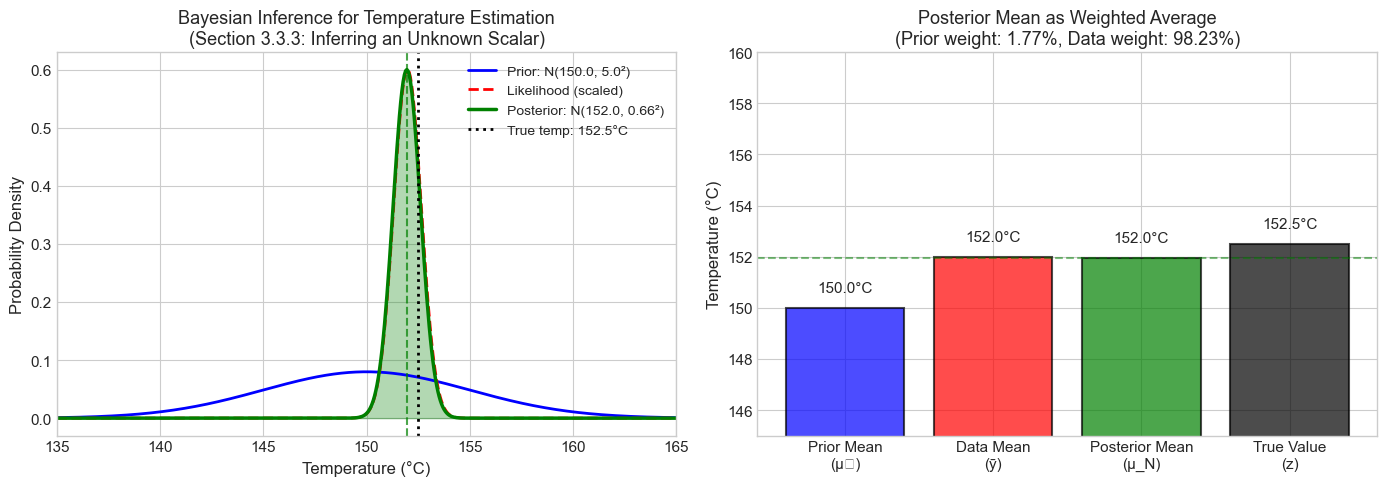


Shrinkage Analysis (Equations 3.61-3.63):
  Weight on prior mean: 1.77%
  Weight on data mean:  98.23%
  μ_N = 0.018 × 150.0 + 0.982 × 151.99 = 151.95°C


In [6]:
# Create temperature range for plotting
z_range = np.linspace(135, 165, 500)

# Prior distribution
prior = stats.norm.pdf(z_range, mu_0, sigma_0)

# Likelihood (as a function of z, given the data mean)
# The likelihood of z given N observations is equivalent to
# N(y_bar | z, sigma_y^2/N), which as a function of z is N(z | y_bar, sigma_y^2/N)
y_bar = np.mean(measurements)
sigma_likelihood = sigma_y / np.sqrt(N_measurements)
likelihood = stats.norm.pdf(z_range, y_bar, sigma_likelihood)

# Posterior distribution
posterior = stats.norm.pdf(z_range, mu_N, sigma_N)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: All three distributions
ax1 = axes[0]
ax1.plot(z_range, prior, 'b-', linewidth=2, label=f'Prior: N({mu_0}, {sigma_0}²)')
ax1.plot(z_range, likelihood / likelihood.max() * posterior.max(), 'r--', linewidth=2, 
         label=f'Likelihood (scaled)')
ax1.plot(z_range, posterior, 'g-', linewidth=2.5, label=f'Posterior: N({mu_N:.1f}, {sigma_N:.2f}²)')
ax1.axvline(TRUE_TEMPERATURE, color='k', linestyle=':', linewidth=2, label=f'True temp: {TRUE_TEMPERATURE}°C')
ax1.axvline(mu_N, color='g', linestyle='--', alpha=0.7, linewidth=1.5)

ax1.fill_between(z_range, posterior, alpha=0.3, color='green')
ax1.set_xlabel('Temperature (°C)', fontsize=12)
ax1.set_ylabel('Probability Density', fontsize=12)
ax1.set_title('Bayesian Inference for Temperature Estimation\n(Section 3.3.3: Inferring an Unknown Scalar)', fontsize=13)
ax1.legend(loc='upper right', fontsize=10)
ax1.set_xlim(135, 165)

# Plot 2: Show the shrinkage effect (Equation 3.61-3.63)
ax2 = axes[1]

# Weight on prior vs data
w_prior = lambda_0 / lambda_N
w_data = N_measurements * lambda_y / lambda_N

categories = ['Prior Mean\n(μ₀)', 'Data Mean\n(ȳ)', 'Posterior Mean\n(μ_N)', 'True Value\n(z)']
values = [mu_0, y_bar, mu_N, TRUE_TEMPERATURE]
colors = ['blue', 'red', 'green', 'black']

bars = ax2.bar(categories, values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.axhline(y=mu_N, color='green', linestyle='--', alpha=0.5)

# Add value labels
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{val:.1f}°C', ha='center', va='bottom', fontsize=11)

ax2.set_ylabel('Temperature (°C)', fontsize=12)
ax2.set_title(f'Posterior Mean as Weighted Average\n(Prior weight: {w_prior:.2%}, Data weight: {w_data:.2%})', fontsize=13)
ax2.set_ylim(145, 160)

plt.tight_layout()
plt.show()

print(f"\nShrinkage Analysis (Equations 3.61-3.63):")
print(f"  Weight on prior mean: {w_prior:.2%}")
print(f"  Weight on data mean:  {w_data:.2%}")
print(f"  μ_N = {w_prior:.3f} × {mu_0} + {w_data:.3f} × {y_bar:.2f} = {mu_N:.2f}°C")

## 5. Sequential Bayesian Updates

One powerful aspect of Bayesian inference is that we can update our beliefs sequentially as new data arrives (Equations 3.58-3.63):

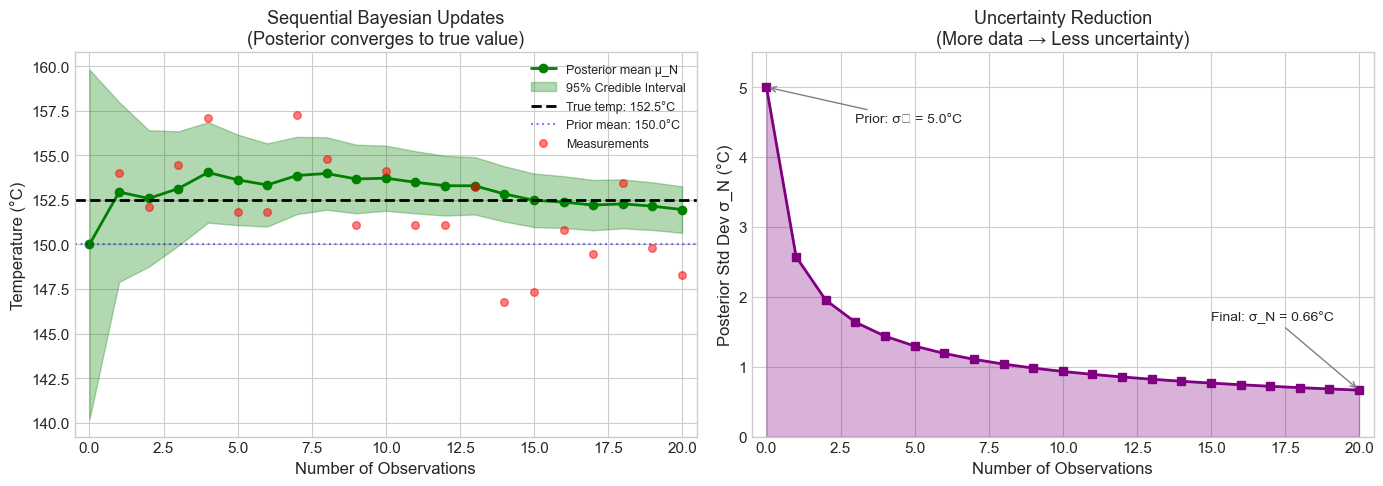


Uncertainty reduction:
  Prior std:     σ₀ = 5.00°C
  Posterior std: σ_N = 0.66°C
  Reduction:     86.7%


In [7]:
def sequential_bayesian_update(measurements, mu_0, sigma_0, sigma_y):
    """
    Perform sequential Bayesian updates, one measurement at a time.
    
    Implements the sequential update from Equations 3.58-3.63.
    """
    mu_history = [mu_0]
    sigma_history = [sigma_0]
    
    mu_current = mu_0
    sigma_current = sigma_0
    
    for y in measurements:
        # Sequential update (Equations 3.59-3.60)
        # Posterior variance (Eq 3.59)
        sigma_new_sq = (sigma_y**2 * sigma_current**2) / (sigma_current**2 + sigma_y**2)
        sigma_new = np.sqrt(sigma_new_sq)
        
        # Posterior mean (Eq 3.60) - convex combination
        mu_new = sigma_new_sq * (mu_current / sigma_current**2 + y / sigma_y**2)
        
        mu_current = mu_new
        sigma_current = sigma_new
        
        mu_history.append(mu_current)
        sigma_history.append(sigma_current)
    
    return np.array(mu_history), np.array(sigma_history)


# Perform sequential updates
mu_seq, sigma_seq = sequential_bayesian_update(measurements, mu_0, sigma_0, sigma_y)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_obs = np.arange(len(mu_seq))

# Plot 1: Evolution of posterior mean
ax1 = axes[0]
ax1.plot(n_obs, mu_seq, 'g-o', linewidth=2, markersize=6, label='Posterior mean μ_N')
ax1.fill_between(n_obs, mu_seq - 1.96*sigma_seq, mu_seq + 1.96*sigma_seq, 
                  alpha=0.3, color='green', label='95% Credible Interval')
ax1.axhline(TRUE_TEMPERATURE, color='black', linestyle='--', linewidth=2, label=f'True temp: {TRUE_TEMPERATURE}°C')
ax1.axhline(mu_0, color='blue', linestyle=':', alpha=0.5, label=f'Prior mean: {mu_0}°C')

# Mark individual measurements
ax1.scatter(n_obs[1:], measurements, color='red', alpha=0.5, s=30, zorder=5, label='Measurements')

ax1.set_xlabel('Number of Observations', fontsize=12)
ax1.set_ylabel('Temperature (°C)', fontsize=12)
ax1.set_title('Sequential Bayesian Updates\n(Posterior converges to true value)', fontsize=13)
ax1.legend(loc='upper right', fontsize=9)
ax1.set_xlim(-0.5, N_measurements + 0.5)

# Plot 2: Evolution of uncertainty
ax2 = axes[1]
ax2.plot(n_obs, sigma_seq, 'purple', linewidth=2, marker='s', markersize=6)
ax2.fill_between(n_obs, 0, sigma_seq, alpha=0.3, color='purple')

ax2.set_xlabel('Number of Observations', fontsize=12)
ax2.set_ylabel('Posterior Std Dev σ_N (°C)', fontsize=12)
ax2.set_title('Uncertainty Reduction\n(More data → Less uncertainty)', fontsize=13)
ax2.set_xlim(-0.5, N_measurements + 0.5)
ax2.set_ylim(0, sigma_0 * 1.1)

# Add annotations
ax2.annotate(f'Prior: σ₀ = {sigma_0:.1f}°C', xy=(0, sigma_0), 
             xytext=(3, sigma_0 - 0.5), fontsize=10,
             arrowprops=dict(arrowstyle='->', color='gray'))
ax2.annotate(f'Final: σ_N = {sigma_seq[-1]:.2f}°C', xy=(N_measurements, sigma_seq[-1]), 
             xytext=(N_measurements - 5, sigma_seq[-1] + 1), fontsize=10,
             arrowprops=dict(arrowstyle='->', color='gray'))

plt.tight_layout()
plt.show()

print(f"\nUncertainty reduction:")
print(f"  Prior std:     σ₀ = {sigma_0:.2f}°C")
print(f"  Posterior std: σ_N = {sigma_seq[-1]:.2f}°C")
print(f"  Reduction:     {(1 - sigma_seq[-1]/sigma_0)*100:.1f}%")

## 6. Effect of Prior Strength (Figure 3.8 Recreation)

Section 3.3.3 discusses how the prior strength affects the posterior. Let's recreate Figure 3.8:

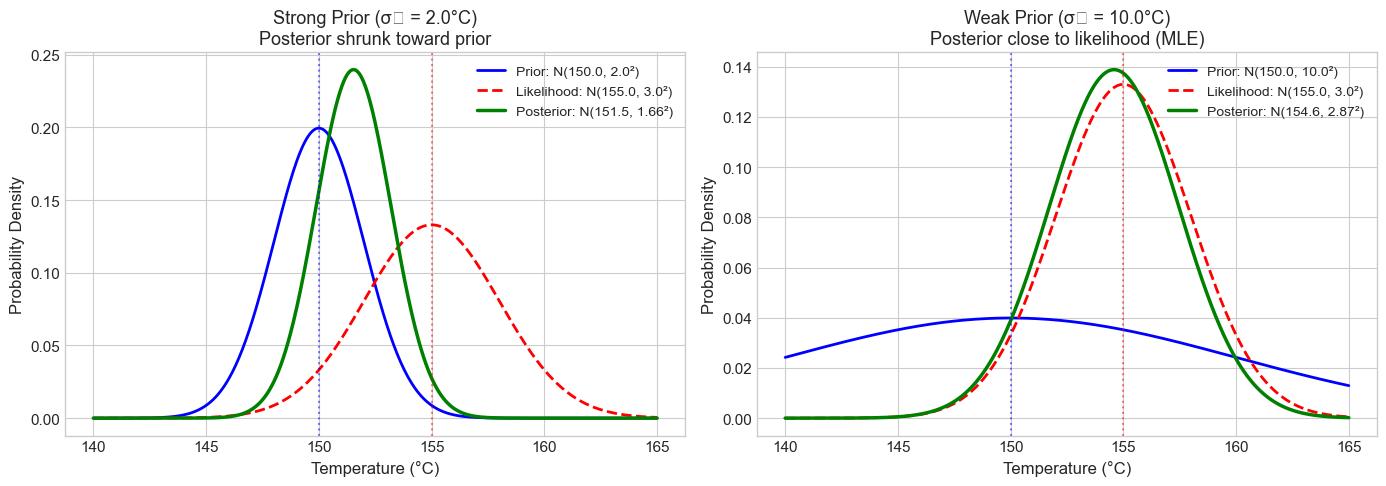


Effect of Prior Strength (single observation y = 155.0°C):

  Strong prior (σ₀ = 2.0°C):
    Posterior mean: 151.54°C (shrunk toward prior μ₀ = 150.0°C)

  Weak prior (σ₀ = 10.0°C):
    Posterior mean: 154.59°C (close to observation y = 155.0°C)


In [8]:
# Single observation for clarity
y_single = 155.0  # A single measurement

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

z_range = np.linspace(140, 165, 500)

# Strong prior (small variance)
sigma_prior_strong = 2.0
mu_post_strong, _, sigma_post_strong = bayesian_update_scalar(
    [y_single], mu_0, 1/sigma_prior_strong**2, lambda_y
)

ax1 = axes[0]
ax1.plot(z_range, stats.norm.pdf(z_range, mu_0, sigma_prior_strong), 'b-', 
         linewidth=2, label=f'Prior: N({mu_0}, {sigma_prior_strong}²)')
ax1.plot(z_range, stats.norm.pdf(z_range, y_single, sigma_y), 'r--', 
         linewidth=2, label=f'Likelihood: N({y_single}, {sigma_y}²)')
ax1.plot(z_range, stats.norm.pdf(z_range, mu_post_strong, sigma_post_strong), 'g-', 
         linewidth=2.5, label=f'Posterior: N({mu_post_strong:.1f}, {sigma_post_strong:.2f}²)')
ax1.axvline(y_single, color='red', linestyle=':', alpha=0.5)
ax1.axvline(mu_0, color='blue', linestyle=':', alpha=0.5)
ax1.set_xlabel('Temperature (°C)', fontsize=12)
ax1.set_ylabel('Probability Density', fontsize=12)
ax1.set_title(f'Strong Prior (σ₀ = {sigma_prior_strong}°C)\nPosterior shrunk toward prior', fontsize=13)
ax1.legend(fontsize=10)

# Weak prior (large variance)
sigma_prior_weak = 10.0
mu_post_weak, _, sigma_post_weak = bayesian_update_scalar(
    [y_single], mu_0, 1/sigma_prior_weak**2, lambda_y
)

ax2 = axes[1]
ax2.plot(z_range, stats.norm.pdf(z_range, mu_0, sigma_prior_weak), 'b-', 
         linewidth=2, label=f'Prior: N({mu_0}, {sigma_prior_weak}²)')
ax2.plot(z_range, stats.norm.pdf(z_range, y_single, sigma_y), 'r--', 
         linewidth=2, label=f'Likelihood: N({y_single}, {sigma_y}²)')
ax2.plot(z_range, stats.norm.pdf(z_range, mu_post_weak, sigma_post_weak), 'g-', 
         linewidth=2.5, label=f'Posterior: N({mu_post_weak:.1f}, {sigma_post_weak:.2f}²)')
ax2.axvline(y_single, color='red', linestyle=':', alpha=0.5)
ax2.axvline(mu_0, color='blue', linestyle=':', alpha=0.5)
ax2.set_xlabel('Temperature (°C)', fontsize=12)
ax2.set_ylabel('Probability Density', fontsize=12)
ax2.set_title(f'Weak Prior (σ₀ = {sigma_prior_weak}°C)\nPosterior close to likelihood (MLE)', fontsize=13)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nEffect of Prior Strength (single observation y = {y_single}°C):")
print(f"\n  Strong prior (σ₀ = {sigma_prior_strong}°C):")
print(f"    Posterior mean: {mu_post_strong:.2f}°C (shrunk toward prior μ₀ = {mu_0}°C)")
print(f"\n  Weak prior (σ₀ = {sigma_prior_weak}°C):")
print(f"    Posterior mean: {mu_post_weak:.2f}°C (close to observation y = {y_single}°C)")

## 7. Signal-to-Noise Ratio Analysis

Section 3.3.3 introduces the Signal-to-Noise Ratio (SNR) as another way to understand shrinkage (Equation 3.64):

$$\text{SNR} = \frac{\mathbb{E}[Z^2]}{\mathbb{E}[\epsilon^2]} = \frac{\Sigma_0 + \mu_0^2}{\Sigma_y}$$

Signal-to-Noise Ratio Analysis (Equation 3.64):
Prior variance (Σ₀): 25.00
Prior mean squared (μ₀²): 22500.00
Noise variance (Σ_y): 9.00

SNR = (Σ₀ + μ₀²) / Σ_y = 2502.78
SNR (dB) = 34.0 dB


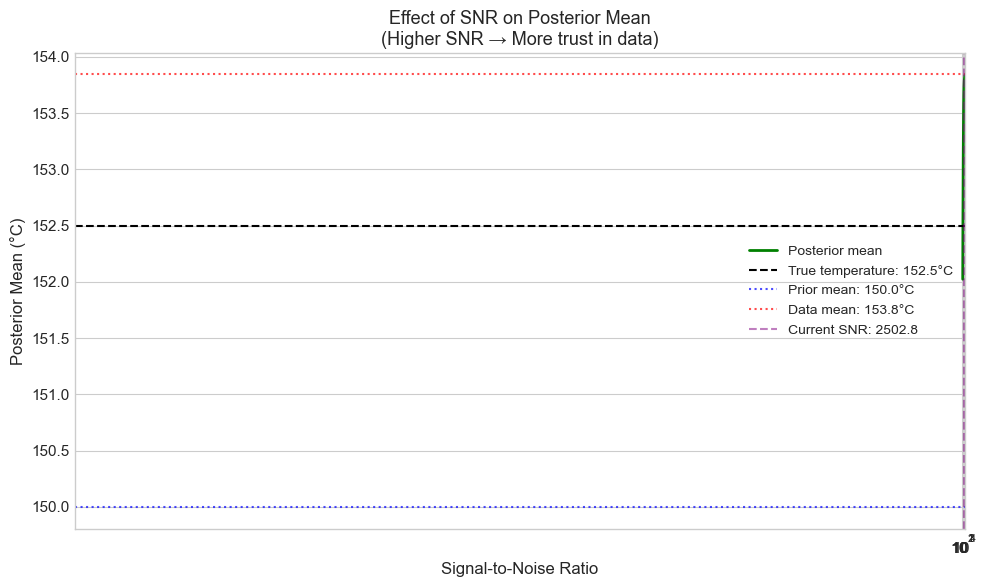

In [8]:
# Calculate SNR
snr = (sigma_0**2 + mu_0**2) / sigma_y**2
snr_db = 10 * np.log10(snr)

print(f"Signal-to-Noise Ratio Analysis (Equation 3.64):")
print(f"="*50)
print(f"Prior variance (Σ₀): {sigma_0**2:.2f}")
print(f"Prior mean squared (μ₀²): {mu_0**2:.2f}")
print(f"Noise variance (Σ_y): {sigma_y**2:.2f}")
print(f"\nSNR = (Σ₀ + μ₀²) / Σ_y = {snr:.2f}")
print(f"SNR (dB) = {snr_db:.1f} dB")

# Visualize how different SNRs affect inference
fig, ax = plt.subplots(figsize=(10, 6))

noise_levels = np.linspace(0.5, 15, 100)
snr_values = (sigma_0**2 + mu_0**2) / noise_levels**2

# Calculate posterior means for different noise levels (with 10 measurements)
posterior_means = []
for noise in noise_levels:
    mu_post, _, _ = bayesian_update_scalar(measurements[:10], mu_0, lambda_0, 1/noise**2)
    posterior_means.append(mu_post)

ax.plot(snr_values, posterior_means, 'g-', linewidth=2, label='Posterior mean')
ax.axhline(TRUE_TEMPERATURE, color='black', linestyle='--', label=f'True temperature: {TRUE_TEMPERATURE}°C')
ax.axhline(mu_0, color='blue', linestyle=':', alpha=0.7, label=f'Prior mean: {mu_0}°C')
ax.axhline(np.mean(measurements[:10]), color='red', linestyle=':', alpha=0.7, 
           label=f'Data mean: {np.mean(measurements[:10]):.1f}°C')

ax.axvline(snr, color='purple', linestyle='--', alpha=0.5, label=f'Current SNR: {snr:.1f}')

ax.set_xlabel('Signal-to-Noise Ratio', fontsize=12)
ax.set_ylabel('Posterior Mean (°C)', fontsize=12)
ax.set_title('Effect of SNR on Posterior Mean\n(Higher SNR → More trust in data)', fontsize=13)
ax.legend(loc='best', fontsize=10)
ax.set_xlim(0, max(snr_values))

# Log scale for x-axis to better show the relationship
ax.set_xscale('log')

plt.tight_layout()
plt.show()

## 8. Practical Application: Quality Control Decision

Let's use our Bayesian estimate to make a quality control decision:

QUALITY CONTROL DECISION

Acceptable temperature range: [145.0°C, 160.0°C]

Bayesian estimate: 151.95°C ± 1.30°C (95% CI)

Probability analysis:
  P(temperature in range):     100.00%
  P(temperature below 145.0°C): 0.0000%
  P(temperature above 160.0°C): 0.0000%

DECISION: PASS - High confidence temperature is within spec


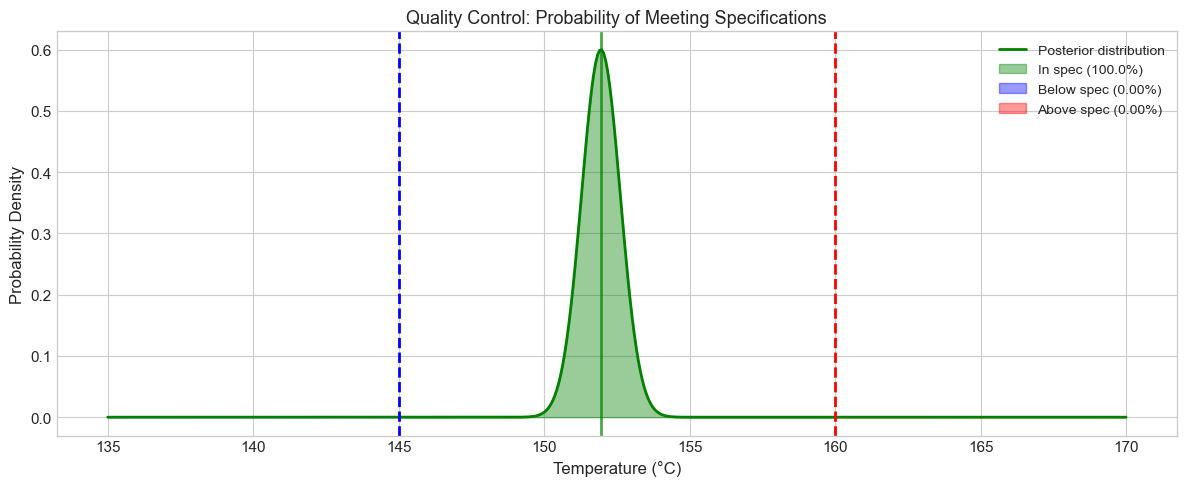

In [9]:
# Quality control thresholds
TEMP_MIN = 145.0  # Minimum acceptable temperature
TEMP_MAX = 160.0  # Maximum acceptable temperature

# Calculate probability that true temperature is within acceptable range
prob_in_range = stats.norm.cdf(TEMP_MAX, mu_N, sigma_N) - stats.norm.cdf(TEMP_MIN, mu_N, sigma_N)

# Calculate probability of being below minimum (risk of under-heating)
prob_below_min = stats.norm.cdf(TEMP_MIN, mu_N, sigma_N)

# Calculate probability of being above maximum (risk of over-heating)
prob_above_max = 1 - stats.norm.cdf(TEMP_MAX, mu_N, sigma_N)

print("=" * 60)
print("QUALITY CONTROL DECISION")
print("=" * 60)
print(f"\nAcceptable temperature range: [{TEMP_MIN}°C, {TEMP_MAX}°C]")
print(f"\nBayesian estimate: {mu_N:.2f}°C ± {1.96*sigma_N:.2f}°C (95% CI)")
print(f"\nProbability analysis:")
print(f"  P(temperature in range):     {prob_in_range:.2%}")
print(f"  P(temperature below {TEMP_MIN}°C): {prob_below_min:.4%}")
print(f"  P(temperature above {TEMP_MAX}°C): {prob_above_max:.4%}")

# Decision
if prob_in_range > 0.95:
    decision = "PASS - High confidence temperature is within spec"
    color = 'green'
elif prob_in_range > 0.80:
    decision = "REVIEW - Moderate confidence, may need additional measurements"
    color = 'orange'
else:
    decision = "FAIL - Low confidence, investigate process"
    color = 'red'

print(f"\n{'='*60}")
print(f"DECISION: {decision}")
print(f"{'='*60}")

# Visualization
fig, ax = plt.subplots(figsize=(12, 5))

z_range = np.linspace(135, 170, 500)
posterior_pdf = stats.norm.pdf(z_range, mu_N, sigma_N)

ax.plot(z_range, posterior_pdf, 'g-', linewidth=2, label='Posterior distribution')
ax.fill_between(z_range, posterior_pdf, where=(z_range >= TEMP_MIN) & (z_range <= TEMP_MAX),
                alpha=0.4, color='green', label=f'In spec ({prob_in_range:.1%})')
ax.fill_between(z_range, posterior_pdf, where=z_range < TEMP_MIN,
                alpha=0.4, color='blue', label=f'Below spec ({prob_below_min:.2%})')
ax.fill_between(z_range, posterior_pdf, where=z_range > TEMP_MAX,
                alpha=0.4, color='red', label=f'Above spec ({prob_above_max:.2%})')

ax.axvline(TEMP_MIN, color='blue', linestyle='--', linewidth=2)
ax.axvline(TEMP_MAX, color='red', linestyle='--', linewidth=2)
ax.axvline(mu_N, color='green', linestyle='-', linewidth=2, alpha=0.7)

ax.set_xlabel('Temperature (°C)', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title('Quality Control: Probability of Meeting Specifications', fontsize=13)
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

## 9. Summary: Key Equations from Section 3.3.3

### The Model
- **Prior**: $p(z) = \mathcal{N}(z | \mu_0, \lambda_0^{-1})$
- **Likelihood**: $p(y_i | z) = \mathcal{N}(y_i | z, \lambda_y^{-1})$

### Posterior After N Observations
$$p(z | \mathbf{y}) = \mathcal{N}(z | \mu_N, \lambda_N^{-1})$$

where:
- **Posterior precision**: $\lambda_N = \lambda_0 + N\lambda_y$ (Eq. 3.53)
- **Posterior mean**: $\mu_N = \frac{N\lambda_y \bar{y} + \lambda_0 \mu_0}{\lambda_N}$ (Eq. 3.54)

### Key Insights
1. **Precision is additive**: Posterior precision = Prior precision + Data precision
2. **Mean is a weighted average**: Posterior mean balances prior and data based on their precisions
3. **Shrinkage**: Strong priors pull the posterior toward the prior mean
4. **More data → Less uncertainty**: Posterior variance decreases as $1/(\lambda_0 + N\lambda_y)$
5. **Sequential updates**: Can update beliefs one observation at a time

In [10]:
# Final summary statistics
print("\n" + "=" * 70)
print("FINAL SUMMARY")
print("=" * 70)
print(f"\nScenario: Industrial Temperature Monitoring")
print(f"True temperature: {TRUE_TEMPERATURE}°C")
print(f"Number of measurements: {N_measurements}")
print(f"\nPrior: μ₀ = {mu_0}°C, σ₀ = {sigma_0}°C")
print(f"Measurement noise: σ_y = {sigma_y}°C")
print(f"\nPosterior: μ_N = {mu_N:.2f}°C, σ_N = {sigma_N:.2f}°C")
print(f"95% Credible Interval: [{mu_N - 1.96*sigma_N:.2f}, {mu_N + 1.96*sigma_N:.2f}]°C")
print(f"\nEstimation error: |μ_N - z| = {abs(mu_N - TRUE_TEMPERATURE):.2f}°C")
print(f"Uncertainty reduction: {(1 - sigma_N/sigma_0)*100:.1f}%")
print("=" * 70)


FINAL SUMMARY

Scenario: Industrial Temperature Monitoring
True temperature: 152.5°C
Number of measurements: 20

Prior: μ₀ = 150.0°C, σ₀ = 5.0°C
Measurement noise: σ_y = 3.0°C

Posterior: μ_N = 151.95°C, σ_N = 0.66°C
95% Credible Interval: [150.65, 153.25]°C

Estimation error: |μ_N - z| = 0.55°C
Uncertainty reduction: 86.7%
